# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [301]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

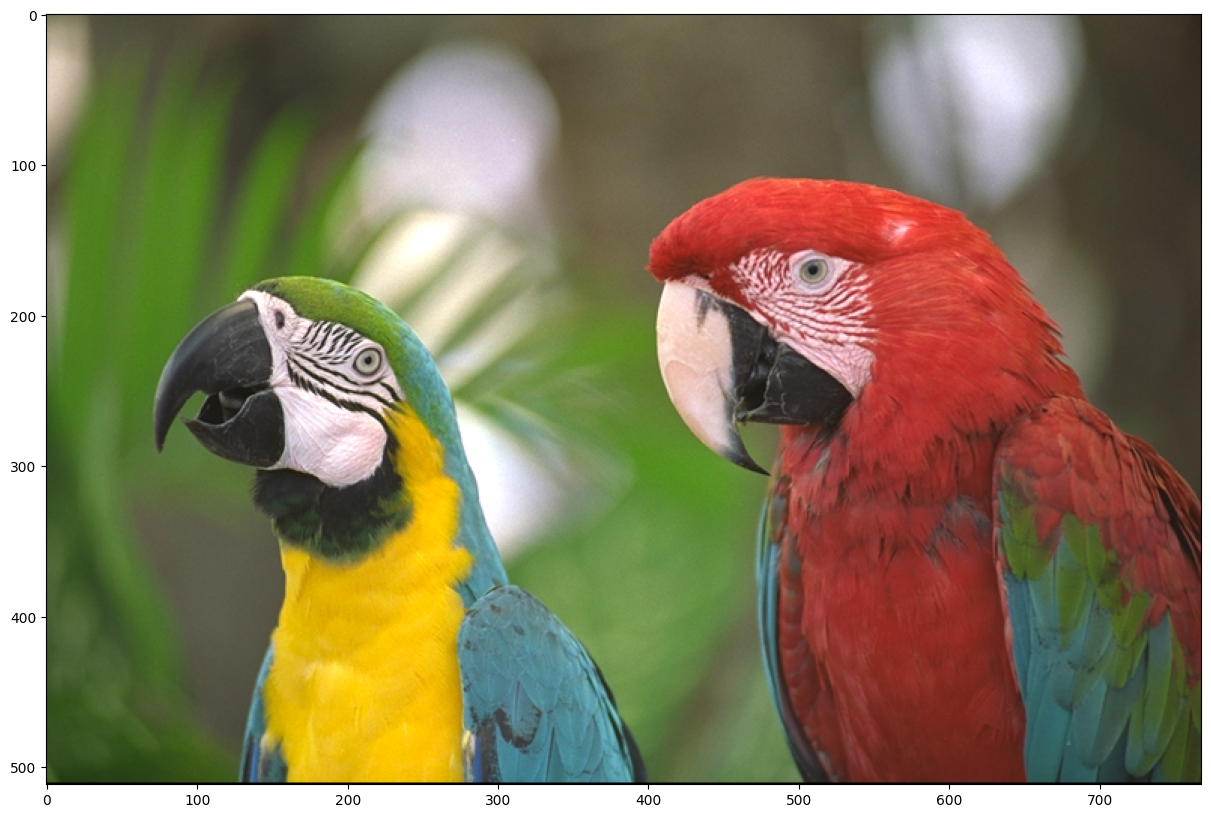

In [494]:
# Load image
img = cv2.imread('data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [497]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

colors_v2 = np.array([[0, 0, 0],
                   [85, 85, 85],
                   [170, 170, 170],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [500]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c]
        
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]
        
        # Apply quantization
        quantized[r, c, :] = new_pixel

(<Axes: >, <matplotlib.image.AxesImage at 0x175f8eab0>)

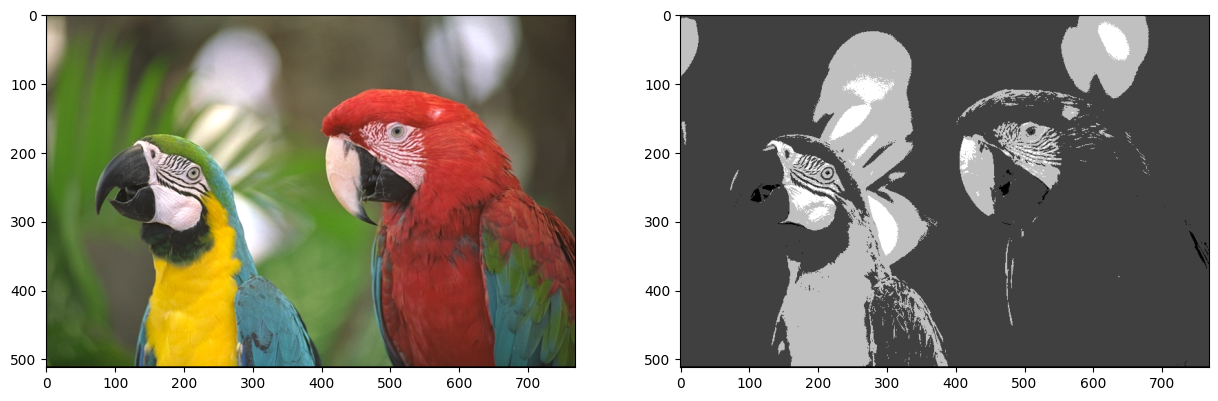

In [501]:
# Show quantized image (don't forget to cast back to uint8)
quantized = np.clip(quantized, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(np.clip(img, 0, 255).astype(np.uint8))
plt.subplot(122), plt.imshow(quantized)

In [504]:
def psnr(ref, target):
    error = ref.astype(np.float32) - target.astype(np.float32)
    mse = np.mean(error**2)
    return 10 * np.log10((255**2)/mse)

In [506]:
# Compute average squared quantization error (PSNR)
avg_quant_error = psnr(img, quantized)
print('PSNR_4', avg_quant_error, 'dB')

PSNR_4 14.826061453276782 dB


результат - сіра картинка з втратами - тому що в палітрі всього 4 кольори (0, 64, 192, 255).
Тобто вся інформація стискається в ці чотири значення, незалежно від оригінального зображення.

16 рівнів

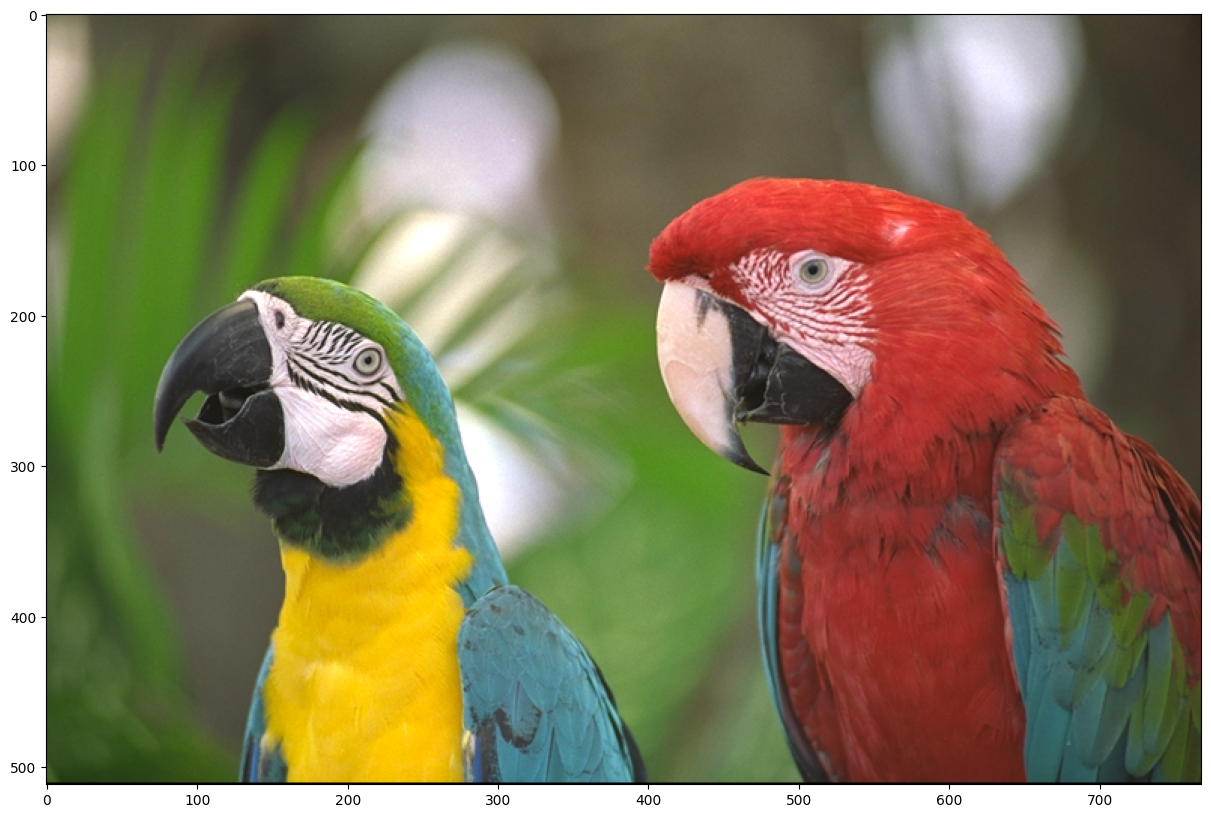

In [511]:
# Load image
img_16 = cv2.imread('data/kodim23.png')
# Convert it to RGB
img_16 = cv2.cvtColor(img_16, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img_16)

In [513]:
palette_16 = np.array([[0, 0, 0],
                   [17, 17, 17],
                   [34, 34, 34],
                   [51, 51, 51],
                   [68, 68, 68],
                   [85, 85, 85],
                   [102, 102, 102],
                   [119, 119, 119],
                   [136, 136, 136],
                   [153, 153, 153],
                   [170, 170, 170],
                   [187, 187, 187],
                   [204, 204, 204],
                   [221, 221, 221],
                   [238, 238, 238],
                   [255, 255, 255]])

In [515]:
# Cast the image to float
img_16 = img_16.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img_16.shape
quantized_16 = np.zeros_like(img_16)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c]
        
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.linalg.norm(palette_16 - pixel, axis=1)
        new_pixel = palette_16[np.argmin(distances)]
        
        # Apply quantization
        quantized_16[r, c, :] = new_pixel

(<Axes: >, <matplotlib.image.AxesImage at 0x1757b66c0>)

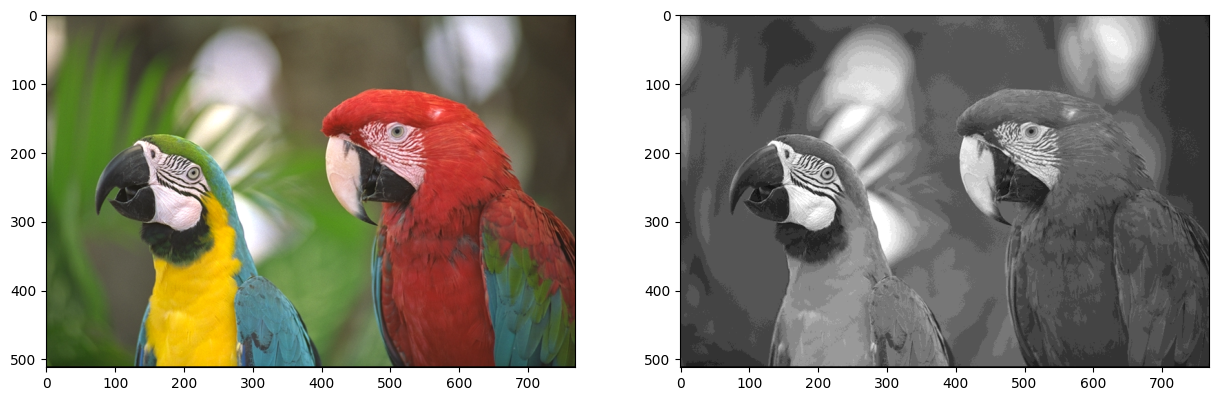

In [516]:
# Show quantized image (don't forget to cast back to uint8)
quantized_16 = np.clip(quantized_16, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(np.clip(img_16, 0, 255).astype(np.uint8))
plt.subplot(122), plt.imshow(quantized_16)

In [519]:
# Compute average squared quantization error (PSNR)
avg_quant_error_16 = psnr(img_16, quantized_16)
print('PSNR_16', avg_quant_error_16, 'dB')

PSNR_16 17.089733528297323 dB


32 рівнів

In [522]:
# Load image
img_32 = cv2.imread('data/kodim23.png')
# Convert it to RGB
img_32 = cv2.cvtColor(img_32, cv2.COLOR_BGR2RGB)

In [524]:
palette_32 = np.array([[0, 0, 0],
                   [8, 8, 8],
                   [16, 16, 16],
                   [24, 24, 24],
                   [33, 33, 33],
                   [41, 41, 41],
                   [49, 49, 49],
                   [57, 57, 57],
                   [66, 66, 66],
                   [74, 74, 74],
                   [82, 82, 82],
                   [90, 90, 90],
                   [99, 99, 99],
                   [107, 107, 107],
                   [115, 115, 115],
                   [123, 123, 123],
                   [132, 132, 132],
                   [140, 140, 140],
                   [148, 148, 148],
                   [156, 156, 156],
                   [165, 165, 165],
                   [173, 173, 173],
                   [181, 181, 181],
                   [189, 189, 189],
                   [198, 198, 198],
                   [206, 206, 206],
                   [214, 214, 214],
                   [222, 222, 222],
                   [231, 231, 231],
                   [239, 239, 239],
                   [247, 247, 247],
                   [255, 255, 255]])

(<Axes: >, <matplotlib.image.AxesImage at 0x17623b350>)

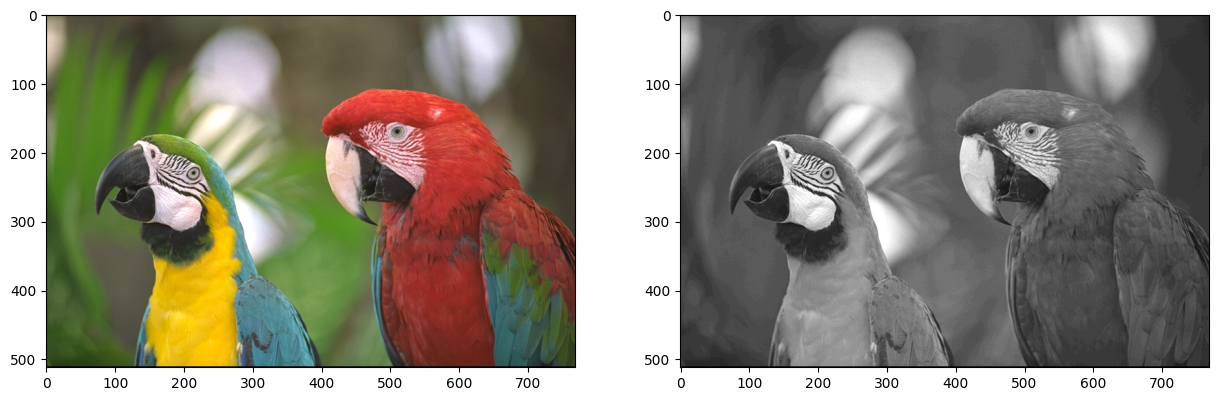

In [526]:
# Cast the image to float
img_32 = img_32.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img_32.shape
quantized_32 = np.zeros_like(img_32)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c]
        
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.linalg.norm(palette_32 - pixel, axis=1)
        new_pixel = palette_32[np.argmin(distances)]
        
        # Apply quantization
        quantized_32[r, c, :] = new_pixel

# Show quantized image (don't forget to cast back to uint8)
quantized_32 = np.clip(quantized_32, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(np.clip(img_32, 0, 255).astype(np.uint8))
plt.subplot(122), plt.imshow(quantized_32)

In [527]:
# Compute average squared quantization error (PSNR)
avg_quant_error_32 = psnr(img_32, quantized_32)
print('PSNR_32', avg_quant_error_32, 'dB')

PSNR_32 17.154247989928876 dB


### Results Optimal quantization:

* PSNR_4 14.826061453276782 dB  [0, 64, 192, 255]
* PSNR_4 15.782689405343064 dB  [0, 85, 170, 255]
* PSNR_16 17.089733528297323 dB
* PSNR_32 17.154247989928876 dB

#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [554]:
# 1. Завантажуємо зображення у відтінках сірого
img_fsd = cv2.imread("data/kodim23.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)

rows, cols = img_fsd.shape

levels = 4
step = 255 / (levels - 1)

In [556]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img_fsd)
dithering = np.zeros_like(img_fsd)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_fsd[r, c]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        new_pixel = round(pixel / step) * step       
        
        # Compute quantization error
        quant_error = pixel - new_pixel
        
        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        img_tmp[r, c + 1] += quant_error * 7 / 16
        img_tmp[r + 1, c - 1] += quant_error * 3 / 16
        img_tmp[r + 1, c] += quant_error * 5 / 16
        img_tmp[r + 1, c + 1] += quant_error * 1 / 16
        
        # Apply dithering
        dithering[r, c] = new_pixel

(<Axes: >, <matplotlib.image.AxesImage at 0x17650e8d0>)

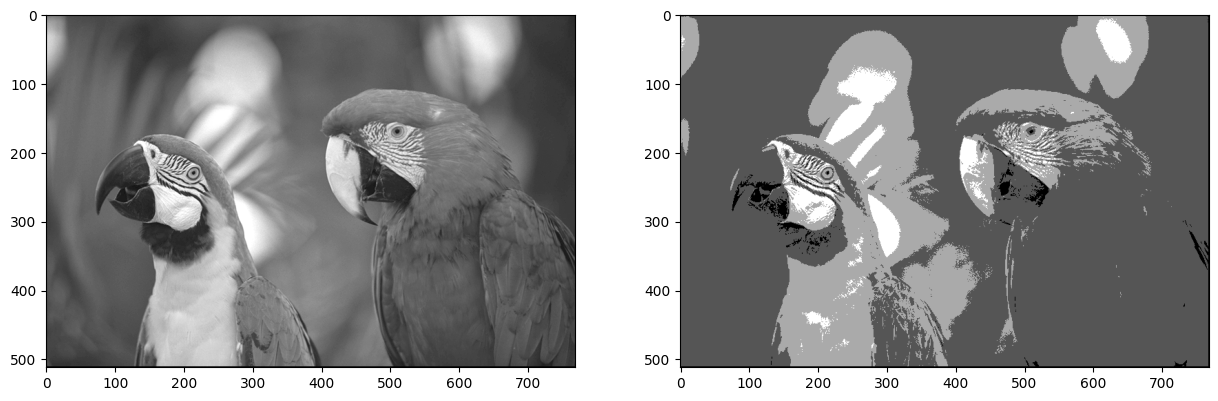

In [558]:
dithering = np.clip(dithering, 0, 255).astype(np.uint8)

# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121), plt.imshow(img_fsd, cmap="gray")
plt.subplot(122), plt.imshow(dithering, cmap="gray")

In [560]:
# Compute average quantization error for dithered image
avg_dith_error = psnr(img_fsd, dithering)

print('PSNR', avg_dith_error, 'dB')

PSNR 20.359576594284793 dB


### Results Floyd-Steinberg Dithering:

* PSNR_2  9.003839639792995 dB
* PSNR_4  20.359576594284793 dB
* PSNR_16 26.05101552527116 dB
* PSNR_32 29.928373078734314 dB

### Questions
* Which image has higher quantization error? Optimally quantized or dithered?
  Оптимальне квантування має більшу похибку.
  Також впливає значення рівнів:
  PSNR_4 14.826061453276782 dB  [0, 64, 192, 255]
  PSNR_4 15.782689405343064 dB  [0, 85, 170, 255]
  при виборі рівнів більш рівномірно результат буде кращим
* Which image looks better to you?
  Для мене краще виглядає зображення після dithered квантування
* Can you repeat the same process using only two colours: black and white? Show me :-)
  це буде дворівневе квантування [0, 255] - результат буде поганим PSNR_2 9.003839639792995 dB

### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

In [543]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_
#colors

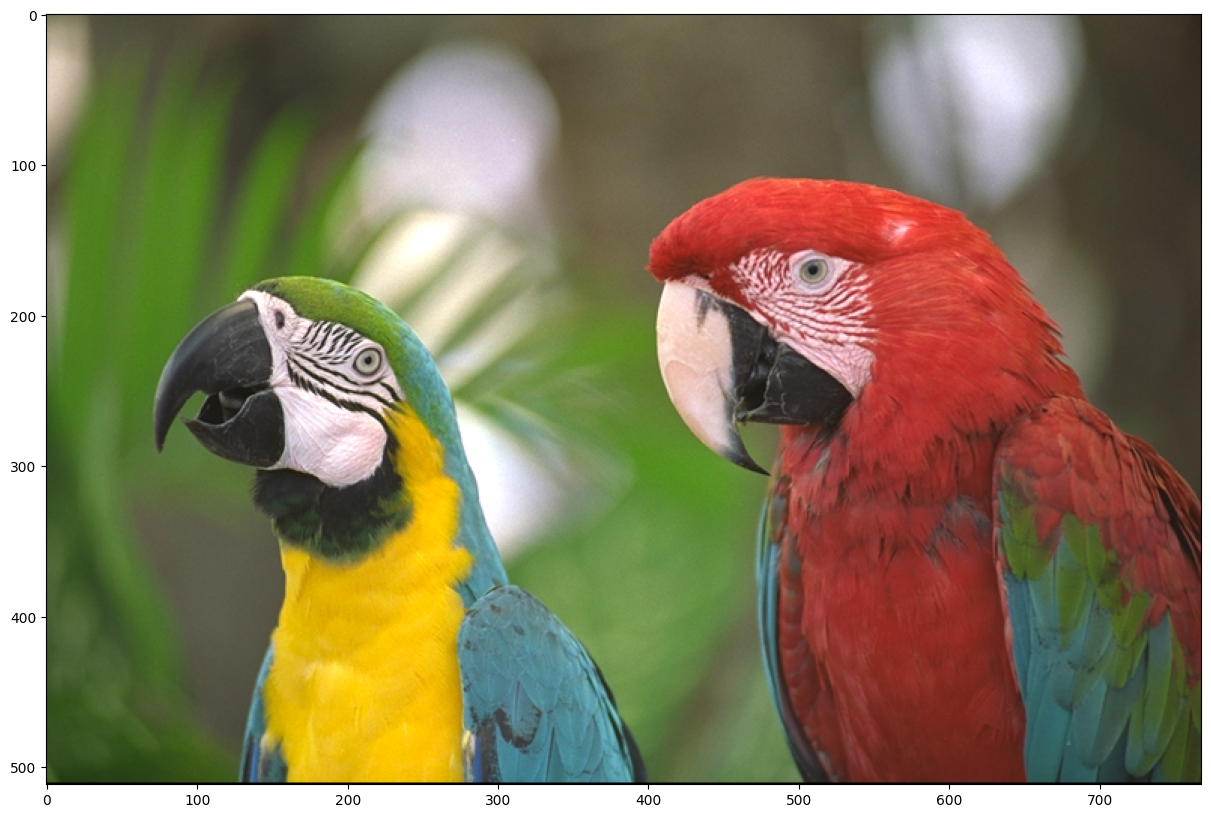

In [545]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Load image
img = cv2.imread('data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

In [547]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c]
        
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]
        
        # Apply quantization
        quantized[r, c, :] = new_pixel

(<Axes: >, <matplotlib.image.AxesImage at 0x17646b6b0>)

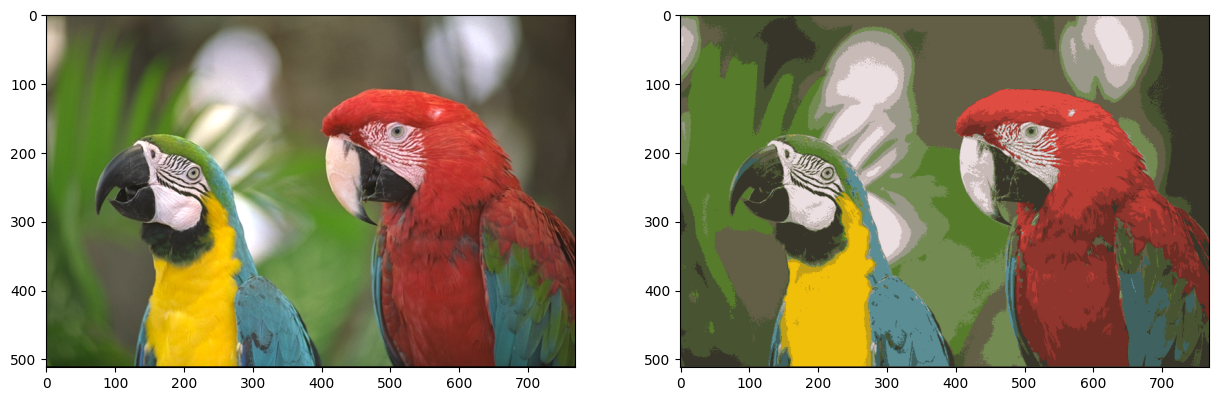

In [548]:
# Show quantized image (don't forget to cast back to uint8)
quantized = np.clip(quantized, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(np.clip(img, 0, 255).astype(np.uint8))
plt.subplot(122), plt.imshow(quantized)

In [551]:
# Compute average squared quantization error (PSNR)
avg_quant_error = psnr(img, quantized)
print('PSNR', avg_quant_error, 'dB')

PSNR 26.43516363734909 dB


Apply FS dithering the same way you did before.
* How does the result look like to you?
   результат виглядає добре. Тому що алгоритм KMeans знаходить вибрану кількість кольорів, що найкраще відображають палітру оригінального зображення
* 16 colours
  PSNR 26.617207151826918 dB
* What happens if we use 32 colours?
  PSNR 29.237363771101368 dB
* And what happens if we use 256 colours?
  PSNR 36.62071666277377 dB

  зі збільшенння кількості кольорів помилка знижується - що є очевидним